In [17]:
import pandas, numpy, sklearn, scipy, matplotlib, seaborn
import torch, torchvision, torchaudio
import transformers, datasets, huggingface_hub, tokenizers
import tqdm, regex, requests, yaml, accelerate
import ipykernel, jupyter_client, jupyter_core, ipywidgets
import IPython, debugpy, jedi, psutil, traitlets, matplotlib_inline, stack_data, prompt_toolkit, pygments, wcwidth

print("✅ Runtime dependencies:")
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("scikit-learn:", sklearn.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", seaborn.__version__)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("torchaudio:", torchaudio.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("tokenizers:", tokenizers.__version__)
print("tqdm:", tqdm.__version__)
print("regex:", regex.__version__)
print("requests:", requests.__version__)
print("PyYAML:", yaml.__version__)
print("accelerate:", accelerate.__version__)
print("ipykernel:", ipykernel.__version__)
print("jupyter_client:", jupyter_client.__version__)
print("jupyter_core:", jupyter_core.__version__)
print("ipywidgets:", ipywidgets.__version__)

print("\n✅ Dev dependencies:")
print("IPython:", IPython.__version__)
print("debugpy:", debugpy.__version__)
print("jedi:", jedi.__version__)
print("psutil:", psutil.__version__)
print("traitlets:", traitlets.__version__)
print("matplotlib-inline:", matplotlib_inline.__version__)
print("stack-data:", stack_data.__version__)
print("prompt_toolkit:", prompt_toolkit.__version__)
print("Pygments:", pygments.__version__)
print("wcwidth:", wcwidth.__version__)


✅ Runtime dependencies:
pandas: 2.2.2
numpy: 1.26.4
scikit-learn: 1.5.1
scipy: 1.14.1
matplotlib: 3.9.2
seaborn: 0.13.2
torch: 2.5.1+cu121
torchvision: 0.20.1+cu121
torchaudio: 2.5.1+cu121
transformers: 4.44.2
datasets: 3.0.1
huggingface_hub: 0.23.2
tokenizers: 0.19.1
tqdm: 4.66.4
regex: 2.5.147
requests: 2.32.3
PyYAML: 6.0.2
accelerate: 0.33.0
ipykernel: 6.29.5
jupyter_client: 8.6.0
jupyter_core: 5.7.2
ipywidgets: 8.1.2

✅ Dev dependencies:
IPython: 8.26.0
debugpy: 1.8.2
jedi: 0.19.1
psutil: 6.0.0
traitlets: 5.14.3
matplotlib-inline: 0.1.7
stack-data: 0.6.3
prompt_toolkit: 3.0.43
Pygments: 2.18.0
wcwidth: 0.2.13


In [18]:
import pandas as pd
df = pd.read_csv("D:\Hiver Assigement\Hiver-SDE-Intern-Project\data\processed\AmazonHelp.csv")
sample = df.sample(300, random_state=42)
sample.to_csv("D:\Hiver Assigement\Hiver-SDE-Intern-Project\data\golden_set.csv", index=False)


In [19]:
import os

# Ensure the folder exists
os.makedirs("data", exist_ok=True)

# Now save
df.to_csv("data/golden_set_labeled.csv", index=False)


In [20]:
import pandas as pd

# Load your golden set
df = pd.read_csv("D:\Hiver Assigement\Hiver-SDE-Intern-Project\data\golden_set.csv")

# Define keyword-based rules
def assign_intent(text):
    text = str(text).lower()
    if "refund" in text or "return" in text:
        return "return_refund"
    elif "delivery" in text or "parcel" in text or "shipping" in text or "delay" in text:
        return "delivery_delay"
    elif "account" in text or "login" in text or "unlock" in text or "password" in text:
        return "account_access"
    elif "charged" in text or "payment" in text or "billing" in text or "credit card" in text:
        return "billing_problem"
    elif "price" in text or "product" in text or "kindle" in text:
        return "product_query"
    elif "thank you" in text or "great" in text or "maravilhoso" in text or "bien" in text:
        return "praise"
    elif "sorry" in text or "apologies" in text or "frustration" in text or "unacceptable" in text:
        return "complaint_unresolved"
    else:
        return "order_issue"  # default fallback

def assign_escalation(intent):
    if intent in ["billing_problem", "account_access", "complaint_unresolved"]:
        return "escalate"
    else:
        return "auto"

# Apply rules
df["intent"] = df["clean_text"].apply(assign_intent)
df["escalation_decision"] = df["intent"].apply(assign_escalation)

# Save labeled file
df.to_csv("data/golden_set_labeled.csv", index=False)

print("✅ Labeled golden_set saved to data/golden_set_labeled.csv")


✅ Labeled golden_set saved to data/golden_set_labeled.csv


In [21]:
import pandas as pd

df = pd.read_csv("data/golden_set_labeled.csv")
print(df.head()[["clean_text", "intent", "escalation_decision"]])


                                          clean_text                intent  \
0  @347092 you're welcome, aditi. do keep us post...           order_issue   
1  @221291 the shipping option you select during ...        delivery_delay   
2  @164542 おはようございます。amazonです。ご利用ありがとうございます！到着までい...           order_issue   
3  @300938 hey, sorry to hear about the trouble! ...  complaint_unresolved   
4  "@317330 about a lower price"" link in the pro...         product_query   

  escalation_decision  
0                auto  
1                auto  
2                auto  
3            escalate  
4                auto  


In [22]:
print(df["intent"].value_counts())


intent
order_issue             167
complaint_unresolved     47
delivery_delay           32
account_access           19
praise                   16
return_refund            11
product_query             7
billing_problem           1
Name: count, dtype: int64


In [23]:
import pandas as pd

# Load labeled dataset
df = pd.read_csv("data/golden_set_labeled.csv")

# Check distribution
print("Before balancing:\n", df["intent"].value_counts())

# Upsample minority classes
balanced_df = (
    df.groupby("intent", group_keys=False)
      .apply(lambda x: x.sample(df["intent"].value_counts().max(), 
                                replace=True, random_state=42))
)

# Verify new distribution
print("\nAfter balancing:\n", balanced_df["intent"].value_counts())

# Save balanced dataset
balanced_df.to_csv("data/golden_set_balanced.csv", index=False)
print("✅ Balanced dataset saved to data/golden_set_balanced.csv")


Before balancing:
 intent
order_issue             167
complaint_unresolved     47
delivery_delay           32
account_access           19
praise                   16
return_refund            11
product_query             7
billing_problem           1
Name: count, dtype: int64

After balancing:
 intent
account_access          167
billing_problem         167
complaint_unresolved    167
delivery_delay          167
order_issue             167
praise                  167
product_query           167
return_refund           167
Name: count, dtype: int64
✅ Balanced dataset saved to data/golden_set_balanced.csv


C:\Users\ASUS\AppData\Local\Temp\ipykernel_24964\1644794131.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(df["intent"].value_counts().max(),


In [25]:
# 1. Imports
import pandas as pd
import numpy as np
from datasets import Dataset
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score
import torch

# 2. Load Balanced Golden Set
df = pd.read_csv("data/golden_set_balanced.csv")  # columns: clean_text, intent, escalation_decision

# Encode labels
labels = list(df["intent"].unique())
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}
df["label"] = df["intent"].map(label2id)

# Convert to HuggingFace Dataset
dataset = Dataset.from_pandas(df)

# 3. Tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(batch["clean_text"], padding="max_length", truncation=True)

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.train_test_split(test_size=0.2, seed=42)

# 4. Model
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

# 5. Metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1": f1}

# 6. Training Arguments
training_args = TrainingArguments(
    output_dir="./models/intents",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

# 7. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

# 8. Train
trainer.train()

# 9. Evaluate
metrics = trainer.evaluate()
print("Final Evaluation:", metrics)

# 10. Save Model
trainer.save_model("./models/intents")
tokenizer.save_pretrained("./models/intents")


d:\Hiver Assigement\Hiver-SDE-Intern-Project\.venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Map:   0%|          | 0/1336 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
d:\Hiver Assigement\Hiver-SDE-Intern-Project\.venv\Lib\site-packages\transformers\training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


  0%|          | 0/268 [00:00<?, ?it/s]

{'loss': 1.8005, 'grad_norm': 3.585904359817505, 'learning_rate': 1.626865671641791e-05, 'epoch': 0.75}


...

  0%|          | 0/17 [00:00<?, ?it/s]

{'eval_loss': 0.10985159873962402, 'eval_accuracy': 0.9925373134328358, 'eval_f1': 0.9925579001544003, 'eval_runtime': 136.7434, 'eval_samples_per_second': 1.96, 'eval_steps_per_second': 0.124, 'epoch': 4.0}
{'train_runtime': 6747.5758, 'train_samples_per_second': 0.633, 'train_steps_per_second': 0.04, 'train_loss': 0.7098109748826098, 'epoch': 4.0}


  0%|          | 0/17 [00:00<?, ?it/s]

Final Evaluation: {'eval_loss': 0.15016062557697296, 'eval_accuracy': 0.9925373134328358, 'eval_f1': 0.9925579001544003, 'eval_runtime': 136.5677, 'eval_samples_per_second': 1.962, 'eval_steps_per_second': 0.124, 'epoch': 4.0}


('./models/intents\\tokenizer_config.json',
 './models/intents\\special_tokens_map.json',
 './models/intents\\vocab.txt',
 './models/intents\\added_tokens.json',
 './models/intents\\tokenizer.json')

In [27]:
import os
print(os.listdir("./models/intents"))


['checkpoint-134', 'checkpoint-201', 'checkpoint-268', 'checkpoint-67', 'config.json', 'model.safetensors', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin', 'vocab.txt']


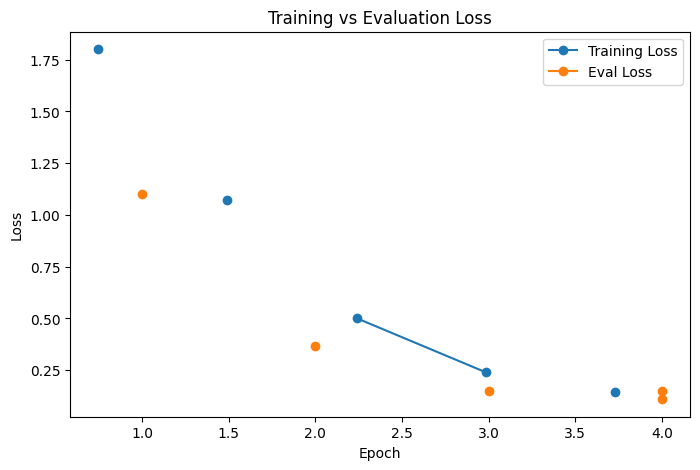

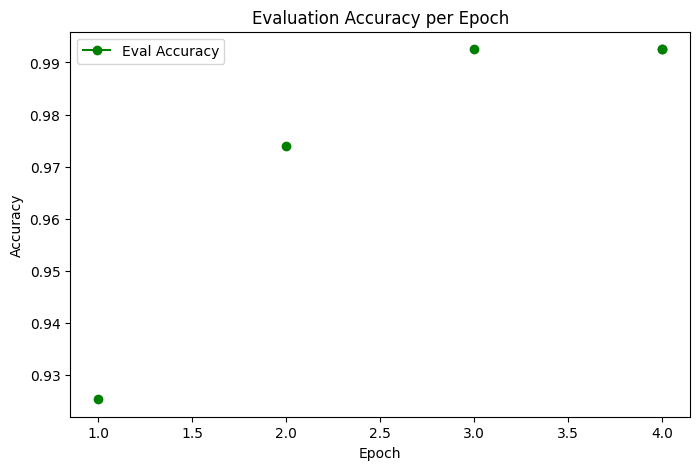

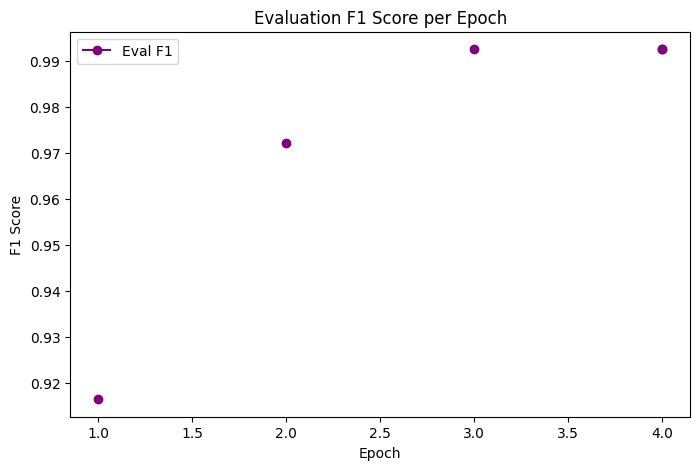

In [26]:
import matplotlib.pyplot as plt

# Extract logs from trainer
training_logs = trainer.state.log_history

# Convert to DataFrame for easier plotting
import pandas as pd
logs_df = pd.DataFrame(training_logs)

# Plot Training Loss
plt.figure(figsize=(8,5))
plt.plot(logs_df["epoch"], logs_df["loss"], label="Training Loss", marker="o")
plt.plot(logs_df["epoch"], logs_df["eval_loss"], label="Eval Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Evaluation Loss")
plt.legend()
plt.show()

# Plot Accuracy
plt.figure(figsize=(8,5))
plt.plot(logs_df["epoch"], logs_df["eval_accuracy"], label="Eval Accuracy", marker="o", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evaluation Accuracy per Epoch")
plt.legend()
plt.show()

# Plot F1 Score
plt.figure(figsize=(8,5))
plt.plot(logs_df["epoch"], logs_df["eval_f1"], label="Eval F1", marker="o", color="purple")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Evaluation F1 Score per Epoch")
plt.legend()
plt.show()


  0%|          | 0/17 [00:00<?, ?it/s]

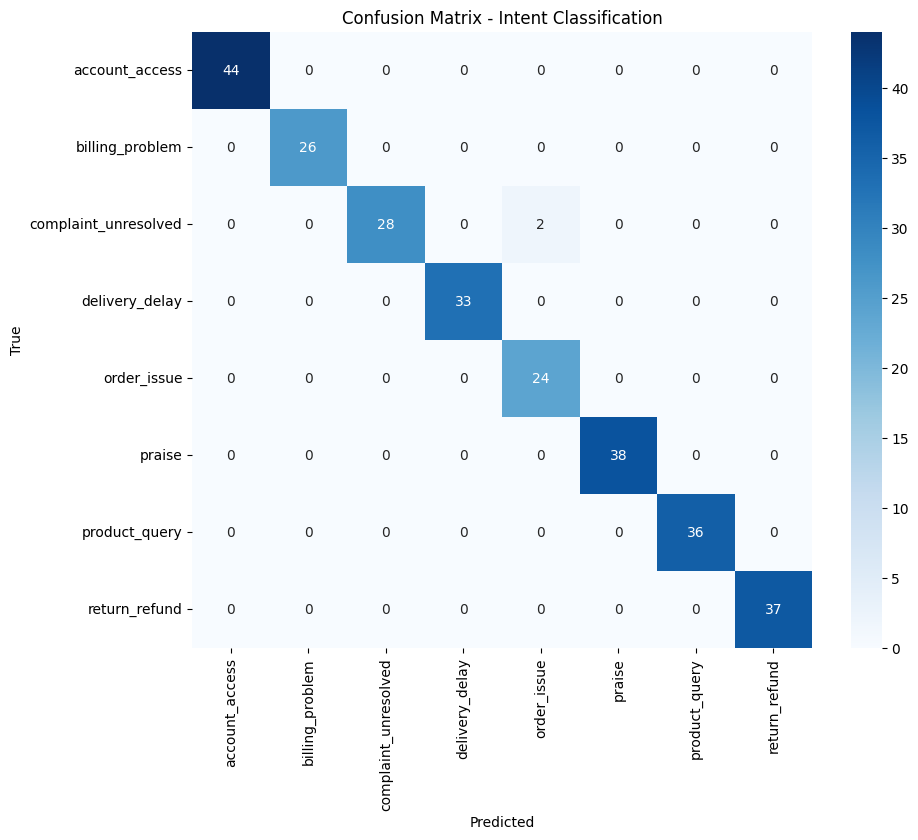

                      precision    recall  f1-score   support

      account_access       1.00      1.00      1.00        44
     billing_problem       1.00      1.00      1.00        26
complaint_unresolved       1.00      0.93      0.97        30
      delivery_delay       1.00      1.00      1.00        33
         order_issue       0.92      1.00      0.96        24
              praise       1.00      1.00      1.00        38
       product_query       1.00      1.00      1.00        36
       return_refund       1.00      1.00      1.00        37

            accuracy                           0.99       268
           macro avg       0.99      0.99      0.99       268
        weighted avg       0.99      0.99      0.99       268



In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions on the test set
predictions = trainer.predict(dataset["test"])
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Intent Classification")
plt.show()

# Classification Report (precision, recall, F1 per class)
print(classification_report(y_true, y_pred, target_names=labels))
